In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [ ]:
# Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Load the DataFrame
import pandas as pd

# Replace 'your_file.csv' with the actual path to your CSV file.
df = pd.read_csv('/content/data.csv')

# Identify target column (assumed 'diagnosis' or first column)
if 'diagnosis' in df.columns:
    target_column = 'diagnosis'
else:
    target_column = df.columns[0]  # fallback

In [ ]:
# Encode target if it's categorical
if df[target_column].dtype == 'object':
    le_target = LabelEncoder()
    df[target_column] = le_target.fit_transform(df[target_column])

# Encode all object (non-numeric) columns in features
for col in df.columns:
    if df[col].dtype == 'object' and col != target_column:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [ ]:
# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

In [ ]:
# Ensure features are numeric before scaling
X = X.apply(pd.to_numeric, errors='coerce')

# Fill any NaNs that may have appeared after coercion
X.fillna(0, inplace=True)

In [ ]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# Initialize list to store results
results = []

In [ ]:
# Models to evaluate
models = {
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

In [ ]:
#Evalution Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=1)
    recall = recall_score(y_test, y_pred, zero_division=1)
    precision = precision_score(y_test, y_pred, zero_division=1)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n====== {name} ======")
    print(f"Accuracy Score:  {acc:.4f}")
    print(f"F1 Score:        {f1:.4f}")
    print(f"Recall:          {recall:.4f}")
    print(f"Precision:       {precision:.4f}")
    print("Confusion Matrix:\n", cm)


    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=1))


====== SVM ======
Accuracy Score:  0.9737
F1 Score:        0.9647
Recall:          0.9535
Precision:       0.9762
Confusion Matrix:
 [[70  1]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


====== Logistic Regression ======
Accuracy Score:  0.9737
F1 Score:        0.9647
Recall:          0.9535
Precision:       0.9762
Confusion Matrix:
 [[70  1]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.

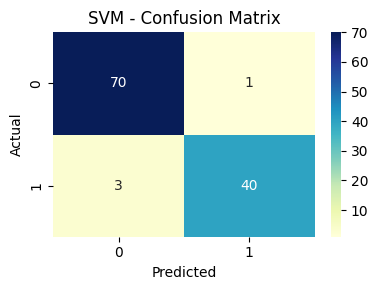

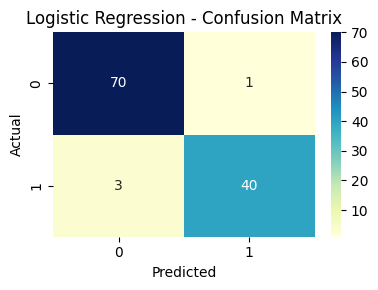

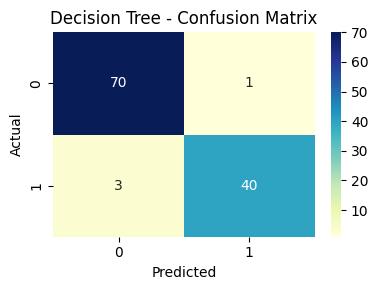

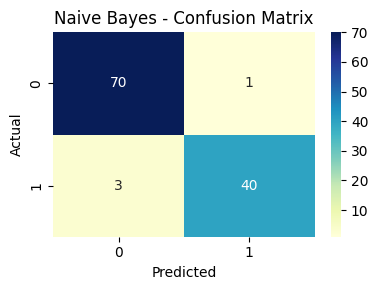

In [ ]:
# Inside the for loop
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # ... other metrics and print statements

    # Confusion matrix visualization
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering

In [ ]:
# Models to evaluate
models = {
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

In [ ]:
# Evaluate supervised models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {name} =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=1))
    print("Confusion Matrix:\n", cm)


===== Random Forest =====
Accuracy:  0.9649
F1 Score:  0.9524
Recall:    0.9302
Precision: 0.9756
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[70  1]
 [ 3 40]]

===== KNN =====
Accuracy:  0.9474
F1 Score:  0.9302
Recall:    0.9302
Precision: 0.9302
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:
 [[68  3]
 [ 3 40]]


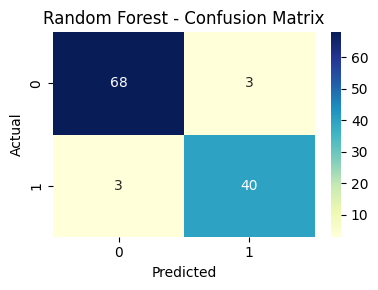

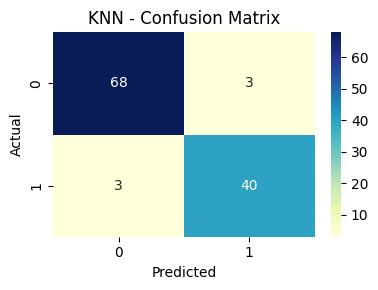

In [ ]:
#Confusion Matrix
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # ... other metrics and print statements

    # Confusion matrix visualization
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [ ]:
# Unsupervised Learning - KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Adjust KMeans labels to match actual
if accuracy_score(y, kmeans_labels) < 0.5:
    kmeans_labels = 1 - kmeans_labels

print("\n===== KMeans (Unsupervised) =====")
print(f"Accuracy:  {accuracy_score(y, kmeans_labels):.4f}")
print(f"F1 Score:  {f1_score(y, kmeans_labels):.4f}")
print(f"Recall:    {recall_score(y, kmeans_labels):.4f}")
print(f"Precision: {precision_score(y, kmeans_labels):.4f}")
print("Classification Report:")
print(classification_report(y, kmeans_labels, zero_division=1))
print("Confusion Matrix:\n", confusion_matrix(y, kmeans_labels))


===== KMeans (Unsupervised) =====
Accuracy:  0.9121
F1 Score:  0.8750
Recall:    0.8255
Precision: 0.9309
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       357
           1       0.93      0.83      0.88       212

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569

Confusion Matrix:
 [[344  13]
 [ 37 175]]


In [ ]:
# Unsupervised Learning - DBSCAN (updated)
# ===== Unsupervised Learning - Hierarchical Clustering =====
print("\n===== Hierarchical Clustering (Agglomerative) =====")
hc = AgglomerativeClustering(n_clusters=2)
hc_labels = hc.fit_predict(X_scaled)

# Optional: flip labels if accuracy is poor
if accuracy_score(y, hc_labels) < 0.5:
    hc_labels = 1 - hc_labels

print(f"Accuracy:  {accuracy_score(y, hc_labels):.4f}")
print(f"F1 Score:  {f1_score(y, hc_labels):.4f}")
print(f"Recall:    {recall_score(y, hc_labels):.4f}")
print(f"Precision: {precision_score(y, hc_labels):.4f}")
print("Classification Report:")
print(classification_report(y, hc_labels, zero_division=1))


===== Hierarchical Clustering (Agglomerative) =====
Accuracy:  0.8805
F1 Score:  0.8283
Recall:    0.7736
Precision: 0.8913
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       357
           1       0.89      0.77      0.83       212

    accuracy                           0.88       569
   macro avg       0.88      0.86      0.87       569
weighted avg       0.88      0.88      0.88       569



<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning Crash Course

<div>

These are a few of the notebooks from Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Linear regression with tf.keras using synthetic data](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [TensorFlow with GPUs](/notebooks/gpu.ipynb)
- [TPUs in Colab](/notebooks/tpu.ipynb)

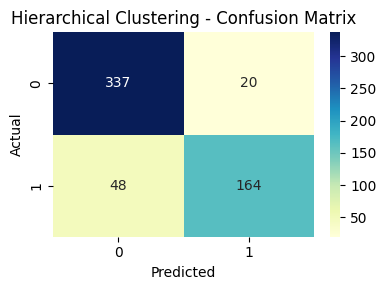

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y, hc_labels)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Hierarchical Clustering - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


===== Logistic Regression =====
Accuracy:  0.9737
Precision: 0.9762
Recall:    0.9535
F1 Score:  0.9647
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[70  1]
 [ 2 41]]


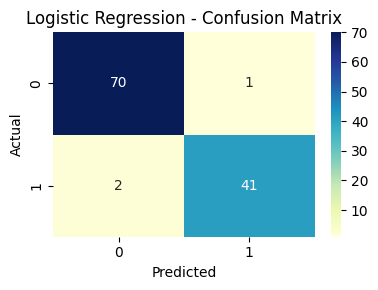


===== SVM =====
Accuracy:  0.9737
Precision: 0.9762
Recall:    0.9535
F1 Score:  0.9647
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[70  1]
 [ 2 41]]


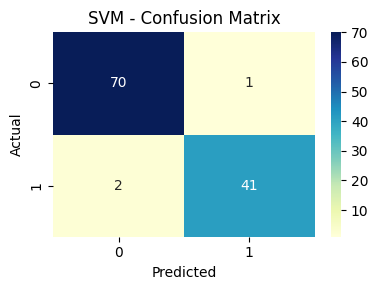


===== Random Forest =====
Accuracy:  0.9649
Precision: 0.9756
Recall:    0.9302
F1 Score:  0.9524
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[70  1]
 [ 3 40]]


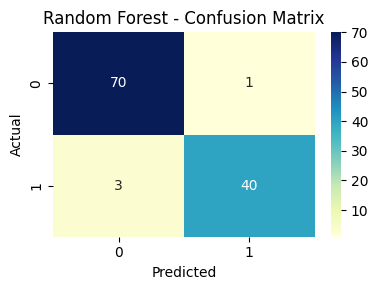


===== KNN =====
Accuracy:  0.9474
Precision: 0.9302
Recall:    0.9302
F1 Score:  0.9302
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:
 [[68  3]
 [ 3 40]]


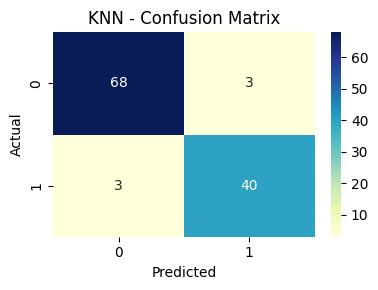


===== Naive Bayes =====
Accuracy:  0.9649
Precision: 0.9756
Recall:    0.9302
F1 Score:  0.9524
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[70  1]
 [ 3 40]]


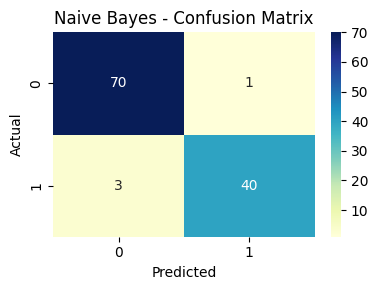


===== Decision Tree =====
Accuracy:  0.9386
Precision: 0.9091
Recall:    0.9302
F1 Score:  0.9195
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95        71
           1       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

Confusion Matrix:
 [[67  4]
 [ 3 40]]


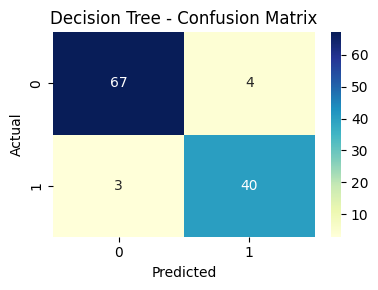

In [ ]:
# Model evaluation function
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=1)
    rec = recall_score(y_true, y_pred, zero_division=1)
    f1 = f1_score(y_true, y_pred, zero_division=1)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    print(f"\n===== {name} =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=1))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Supervised Models
evaluate_model("Logistic Regression", y_test, LogisticRegression().fit(X_train, y_train).predict(X_test))
evaluate_model("SVM", y_test, SVC().fit(X_train, y_train).predict(X_test))
evaluate_model("Random Forest", y_test, RandomForestClassifier().fit(X_train, y_train).predict(X_test))
evaluate_model("KNN", y_test, KNeighborsClassifier().fit(X_train, y_train).predict(X_test))
evaluate_model("Naive Bayes", y_test, GaussianNB().fit(X_train, y_train).predict(X_test))
evaluate_model("Decision Tree", y_test, DecisionTreeClassifier().fit(X_train, y_train).predict(X_test))

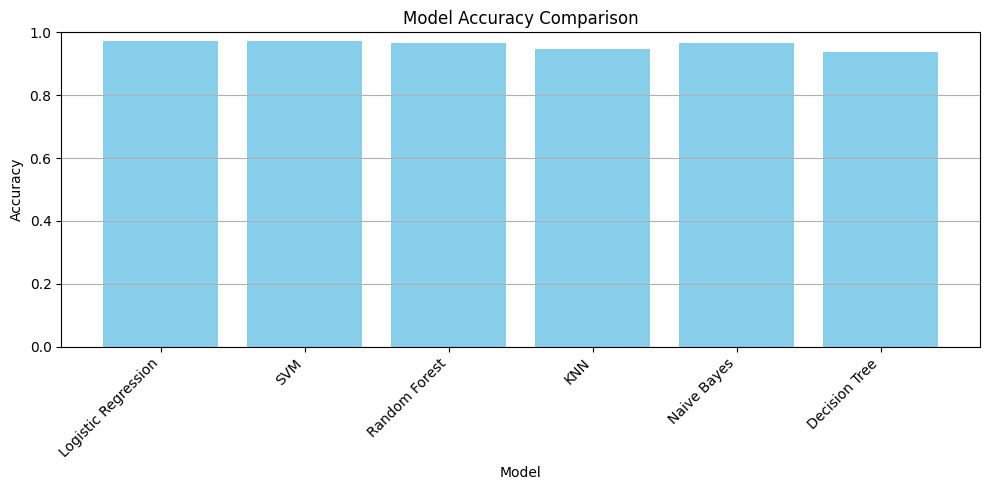

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Drop duplicate or supervised "KMeans" if both are present
results_df = results_df.drop_duplicates(subset='Model')  # In case duplicates exist

# Optional: drop specific unwanted model by name
results_df = results_df[results_df['Model'] != 'KMeans']  # Removes supervised KMeans if needed

# Plot Accuracy comparison only
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Accuracy'], color='skyblue')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

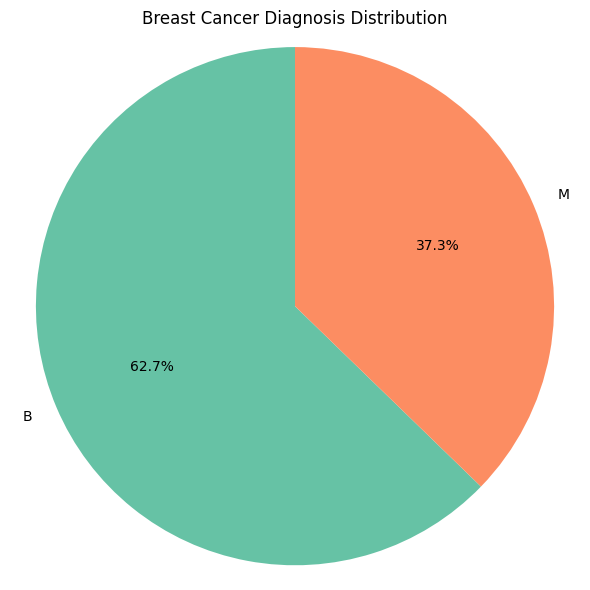

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/data.csv')  # Update path if needed

# Assume target column is named 'diagnosis' — adjust if needed
if 'diagnosis' in df.columns:
    target_col = 'diagnosis'
else:
    target_col = df.columns[0]  # Fallback to first column if unsure

# Count values in target column
diagnosis_counts = df[target_col].value_counts()
labels = diagnosis_counts.index
sizes = diagnosis_counts.values

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Breast Cancer Diagnosis Distribution')
plt.axis('equal')  # Equal aspect ratio to keep it circular
plt.tight_layout()
plt.show()


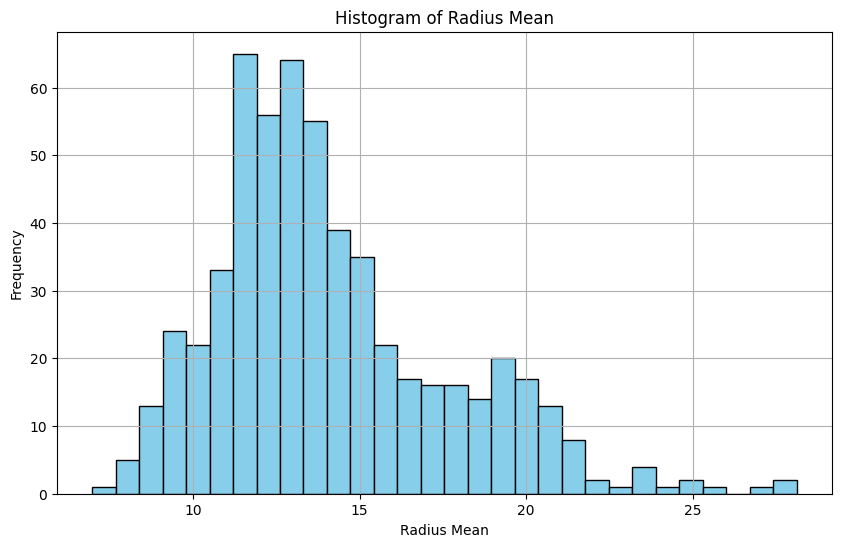

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('/content/data.csv')

# Create a histogram for the 'Radius_mean' column
plt.figure(figsize=(10, 6))
plt.hist(data['Radius_mean'], bins=30, edgecolor='black', color='skyblue')
plt.title('Histogram of Radius Mean')
plt.xlabel('Radius Mean')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
